<a href="https://colab.research.google.com/github/amityadav230816-sys/ML/blob/main/19-03-2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
class MyLinearRegression:
    def __init__(self, weight=0.09, bias=3, learning_rate=0.0009,
                 iterations=344):
        self.weight = float(weight)
        self.bias = float(bias)
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.cost_trend = []
        self.cost = 0

    def predict(self, x):
        predicted_set = []
        for i in range(len(x)):
            x_val = x[i][0] if isinstance(x[i], (list, np.ndarray)) else x[i]
            predicted_value = self.weight * x_val + self.bias
            predicted_set.append(predicted_value)
        return predicted_set

    def cost_function(self, x, y):
        count = len(x)
        total_error = 0.0
        for i in range(count):
            x_val = x[i][0] if isinstance(x[i], (list, np.ndarray)) else x[i]
            total_error += (y[i] - (self.weight * x_val + self.bias)) ** 2
        return total_error / (2 * count)

    def update_weights(self, x, y):
        weight_deriv = 0
        bias_deriv = 0
        count = len(x)

        for i in range(count):
            x_val = x[i][0] if isinstance(x[i], (list, np.ndarray)) else x[i]
            # Calculate partial derivatives
            # -2x(y - (mx + b))
            weight_deriv += -2 * x_val * (y[i] -(self.weight * x_val + self.bias))

            # -2(y - (mx + b))
            bias_deriv += -2 * (y[i] - (self.weight * x_val + self.bias))

        # We subtract because the derivatives point in direction of steepest
        # ascent
        self.weight -= (weight_deriv / count) * self.learning_rate
        self.bias -= (bias_deriv / count) * self.learning_rate

    def train(self, x, y):
        for i in range(self.iterations):
            self.update_weights(x, y)
            # Calculating cost
            self.cost = self.cost_function(x, y)
            self.cost_trend.append(self.cost)
           # if i % 10000 == 0:
            print("Iteration: {}\t Weight: {}\t Bias: {}\t Cost: {}".format(i, self.weight, self.bias, self.cost))

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# intialise data of lists.
data = {'Hours':[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8],
        'Scores':[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]}

# Create DataFrame
studentscores = pd.DataFrame(data)

# Print the output.
studentscores

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


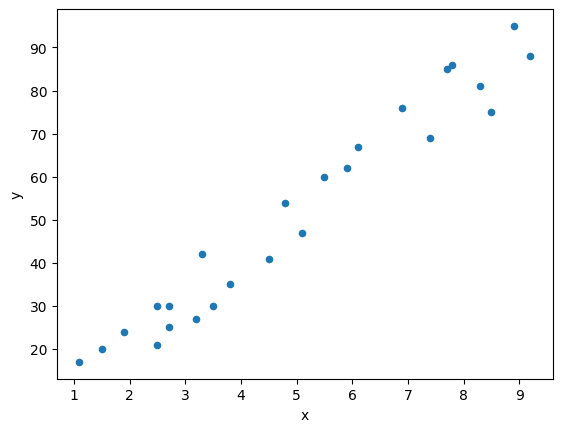

In [14]:
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y,s=20)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
#from my_linear_regression import MyLinearRegression
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Importing the dataset

X = studentscores.iloc[:, :-1].values
y = studentscores.iloc[:, -1].values
X,y

(array([[2.5],
        [5.1],
        [3.2],
        [8.5],
        [3.5],
        [1.5],
        [9.2],
        [5.5],
        [8.3],
        [2.7],
        [7.7],
        [5.9],
        [4.5],
        [3.3],
        [1.1],
        [8.9],
        [2.5],
        [1.9],
        [6.1],
        [7.4],
        [2.7],
        [4.8],
        [3.8],
        [6.9],
        [7.8]]),
 array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30,
        24, 67, 69, 30, 54, 35, 76, 86]))

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Importing the dataset
X = studentscores.iloc[:, :-1].values
y = studentscores.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

# Fitting Simple Linear Regression to the Training set
regressor = MyLinearRegression()
regressor.train(X_train, y_train)
print('Weight: ' + str(regressor.weight) + ' Bias: ' + str(regressor.bias))

# Predicting the Test set results
y_pred = regressor.predict(X_test)

Iteration: 0	 Weight: [0.67527452]	 Bias: [3.09027045]	 Cost: 1375.334763913378
Iteration: 1	 Weight: [1.22372695]	 Bias: [3.17482123]	 Cost: 1209.6346956532095
Iteration: 2	 Weight: [1.73767431]	 Bias: [3.25401227]	 Cost: 1064.1317576156337
Iteration: 3	 Weight: [2.21928781]	 Bias: [3.32818083]	 Cost: 936.3641245109692
Iteration: 4	 Weight: [2.67060205]	 Bias: [3.39764296]	 Cost: 824.1700425811655
Iteration: 5	 Weight: [3.09352361]	 Bias: [3.46269484]	 Cost: 725.6512539238287
Iteration: 6	 Weight: [3.48983907]	 Bias: [3.52361398]	 Cost: 639.1408790201508
Iteration: 7	 Weight: [3.86122261]	 Bias: [3.58066045]	 Cost: 563.1752140569024
Iteration: 8	 Weight: [4.20924308]	 Bias: [3.63407796]	 Cost: 496.46896586880604
Iteration: 9	 Weight: [4.53537057]	 Bias: [3.68409485]	 Cost: 437.8935054902349
Iteration: 10	 Weight: [4.8409827]	 Bias: [3.73092514]	 Cost: 386.457772378375
Iteration: 11	 Weight: [5.12737039]	 Bias: [3.77476934]	 Cost: 341.29150621789023
Iteration: 12	 Weight: [5.39574333]	

/tmp/ipykernel_1184/3405519088.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(total_error) / (2 * count)


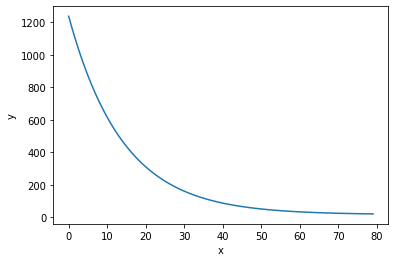

In [ ]:
x=[int(x) for x in range(80)]
y=regressor.cost_trend
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

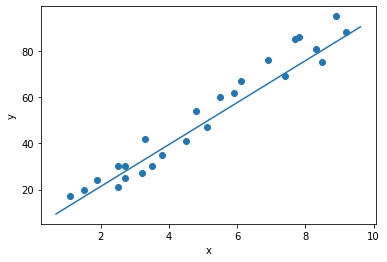

In [ ]:
w = regressor.weight
b = regressor.bias
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y)
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = b + w * x_vals
plt.plot(x_vals, y_vals)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [21]:
# Predicting the Test set results
y_pred = regressor.predict(X_test)

# Simple comparison
print("COMPARISON OF PREDICTED VS ACTUAL VALUES:")
print("-" * 40)
for i in range(len(y_pred)):
    # Convert to float to avoid formatting issues
    pred_val = float(y_pred[i])
    actual_val = float(y_test[i])
    diff = abs(pred_val - actual_val)
    print(f"Predicted: {pred_val:.2f} | Actual: {actual_val:.2f} | Difference: {diff:.2f}")

# Calculate accuracy
errors = []
for i in range(len(y_pred)):
    error = abs(float(y_pred[i]) - float(y_test[i]))
    errors.append(error)

average_error = sum(errors) / len(errors)
print("-" * 40)
print(f"Average Error: {average_error:.2f}")
print(f"Best Prediction: {min(errors):.2f} off")
print(f"Worst Prediction: {max(errors):.2f} off")

COMPARISON OF PREDICTED VS ACTUAL VALUES:
----------------------------------------
Predicted: 18.37 | Actual: 20.00 | Difference: 1.63
Predicted: 34.39 | Actual: 27.00 | Difference: 7.39
Predicted: 73.96 | Actual: 69.00 | Difference: 4.96
Predicted: 27.79 | Actual: 30.00 | Difference: 2.21
Predicted: 59.83 | Actual: 62.00 | Difference: 2.17
Predicted: 40.04 | Actual: 35.00 | Difference: 5.04
Predicted: 22.14 | Actual: 24.00 | Difference: 1.86
Predicted: 77.73 | Actual: 86.00 | Difference: 8.27
Predicted: 69.25 | Actual: 76.00 | Difference: 6.75
----------------------------------------
Average Error: 4.48
Best Prediction: 1.63 off
Worst Prediction: 8.27 off


/tmp/ipykernel_1184/1108160880.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_val = float(y_pred[i])
/tmp/ipykernel_1184/1108160880.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  error = abs(float(y_pred[i]) - float(y_test[i]))
